In [85]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Display settings
sns.set(style="whitegrid")

In [86]:
import os
os.getcwd()

'/Users/abhisheksmac/Desktop/IT Career Switch/Portfolio Project Student Placement Prediction Dataset 2026/Dataset'

In [87]:
os.chdir('/Users/abhisheksmac/Desktop/IT Career Switch/Portfolio Project Student Placement Prediction Dataset 2026/Dataset')

# Step 1: Load and Check Data

In [88]:
df = pd.read_csv("data.csv")

In [89]:
print(df.head())

   student_id  age  gender  cgpa branch college_tier  internships_count  \
0           1   24    Male  7.53     IT       Tier 2                  4   
1           2   21    Male  7.92    CSE       Tier 2                  1   
2           3   22  Female  8.60    EEE       Tier 1                  0   
3           4   24    Male  6.68    CSE       Tier 1                  0   
4           5   20  Female  8.43     IT       Tier 3                  1   

   projects_count  certifications_count  coding_skill_score  ...  \
0               6                     1           99.238568  ...   
1               3                     6           80.966123  ...   
2               1                     1           49.177184  ...   
3               2                     2           79.359084  ...   
4               4                     3           65.018573  ...   

   mock_interview_score  attendance_percentage  backlogs  \
0             72.647009              77.463863         2   
1             61.699

In [90]:
df.describe()

,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


In [91]:
# Loading data types, we already know there are no missing values  
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [92]:
print(df.columns)

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')


## Observations

1. Each row represents one student → correct granularity
2. Dataset size: 100,000 rows → strong statistical reliability
3. Contains both:
   i. Academic features (CGPA, backlogs)
   ii. Skill-based features (coding, communication)
   iii. Outcome variables (placement, salary)

# Step 2: Data Wrangling and Tidying

In [93]:
# Check Missing Values
print(df.isnull().sum())

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64


In [94]:
# No missing values → no imputation needed

In [95]:
print(df.dtypes)

student_id                     int64
age                            int64
gender                        object
cgpa                         float64
branch                        object
college_tier                  object
internships_count              int64
projects_count                 int64
certifications_count           int64
coding_skill_score           float64
aptitude_score               float64
communication_skill_score    float64
logical_reasoning_score      float64
hackathons_participated        int64
github_repos                   int64
linkedin_connections           int64
mock_interview_score         float64
attendance_percentage        float64
backlogs                       int64
extracurricular_score        float64
leadership_score             float64
volunteer_experience          object
sleep_hours                  float64
study_hours_per_day          float64
placement_status              object
salary_package_lpa           float64
dtype: object


In [96]:
# Dropping irrelevant column "student_id"

df.drop('student_id', axis=1, inplace=True)

In [97]:
# Create meaningful features

df['total_experience'] = (
    df['internships_count'] +
    df['projects_count'] +
    df['hackathons_participated']
)

df['skill_score'] = (
    df['coding_skill_score'] +
    df['aptitude_score'] +
    df['communication_skill_score']
) / 3

df = df.drop(['internships_count', 'projects_count', 'hackathons_participated', 'coding_skill_score', 'aptitude_score', 'communication_skill_score'], axis=1)

df.head()

,age,gender,cgpa,branch,college_tier,certifications_count,logical_reasoning_score,github_repos,linkedin_connections,mock_interview_score,...,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa,total_experience,skill_score
0,24,Male,7.53,IT,Tier 2,1,59.070073,1,184,72.647009,...,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00,14,79.551152
1,21,Male,7.92,CSE,Tier 2,6,78.976419,2,539,61.699110,...,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00,4,67.759975
2,22,Female,8.60,EEE,Tier 1,1,80.603331,2,568,87.396911,...,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99,1,63.313608
3,24,Male,6.68,CSE,Tier 1,2,64.187246,1,550,58.401069,...,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00,3,76.382512
4,20,Female,8.43,IT,Tier 3,3,56.163678,4,833,74.489201,...,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16,6,71.749963


In [98]:
print(df.describe())

                 age           cgpa  certifications_count  \
count  100000.000000  100000.000000         100000.000000   
mean       21.005740       7.496890              2.005150   
std         1.999562       0.992834              1.416553   
min        18.000000       4.500000              0.000000   
25%        19.000000       6.820000              1.000000   
50%        21.000000       7.500000              2.000000   
75%        23.000000       8.180000              3.000000   
max        24.000000      10.000000             11.000000   

       logical_reasoning_score   github_repos  linkedin_connections  \
count            100000.000000  100000.000000         100000.000000   
mean                 65.931696       4.005160            524.559110   
std                  14.826790       2.004897            274.993479   
min                  20.000000       0.000000             50.000000   
25%                  55.940547       3.000000            287.000000   
50%                  66.

# Step 3: Exploratory Data Analysis (EDA)

In [99]:
# Descriptive Statistics

print(df.describe())

                 age           cgpa  certifications_count  \
count  100000.000000  100000.000000         100000.000000   
mean       21.005740       7.496890              2.005150   
std         1.999562       0.992834              1.416553   
min        18.000000       4.500000              0.000000   
25%        19.000000       6.820000              1.000000   
50%        21.000000       7.500000              2.000000   
75%        23.000000       8.180000              3.000000   
max        24.000000      10.000000             11.000000   

       logical_reasoning_score   github_repos  linkedin_connections  \
count            100000.000000  100000.000000         100000.000000   
mean                 65.931696       4.005160            524.559110   
std                  14.826790       2.004897            274.993479   
min                  20.000000       0.000000             50.000000   
25%                  55.940547       3.000000            287.000000   
50%                  66.

## Univariate Analysis

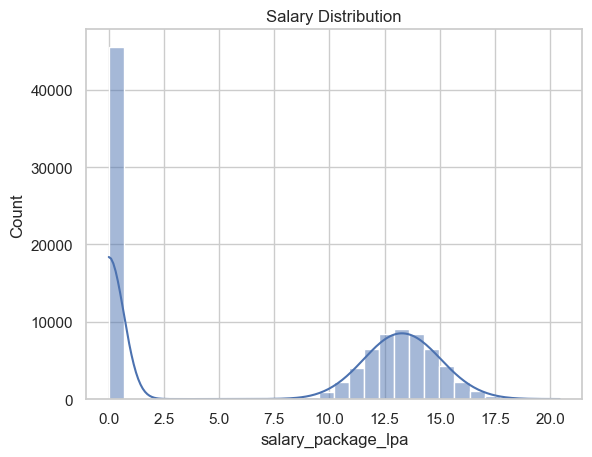

In [100]:
# Salary Distribution

plt.figure()
sns.histplot(df['salary_package_lpa'], bins=30, kde=True)
plt.title("Salary Distribution")
plt.show()

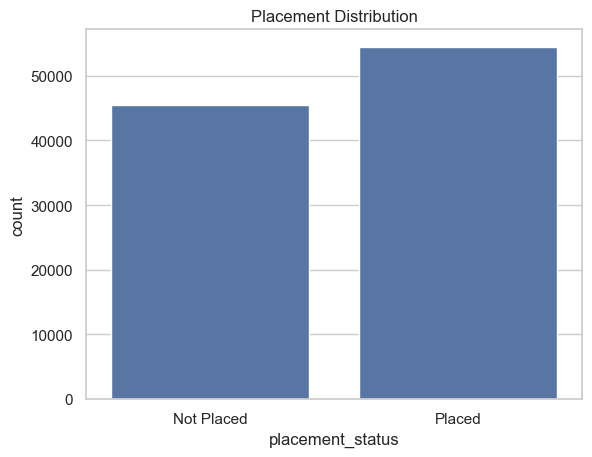

In [101]:
# Placement Distribution

sns.countplot(x='placement_status', data=df)
plt.title("Placement Distribution")
plt.show()

## Bivariate Analysis

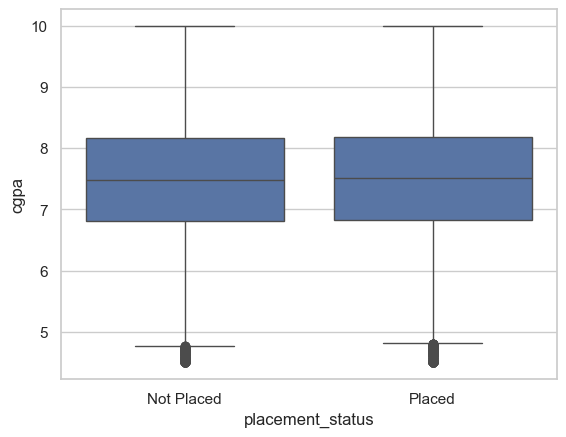

In [102]:
# CGPA vs Placement

sns.boxplot(x='placement_status', y='cgpa', data=df)
plt.show()

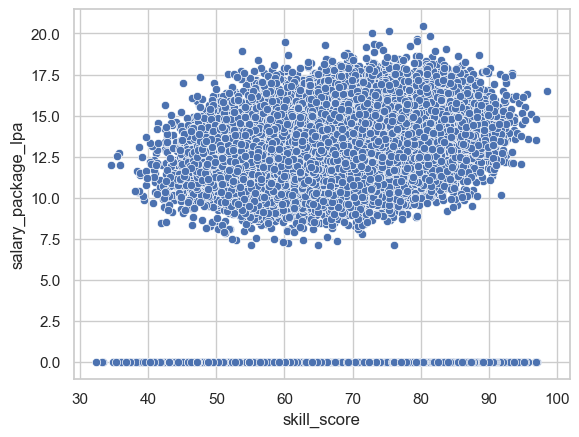

In [104]:
# Coding Skill vs Salary

sns.scatterplot(x='skill_score', y='salary_package_lpa', data=df)
plt.show()

## Correlation Analysis

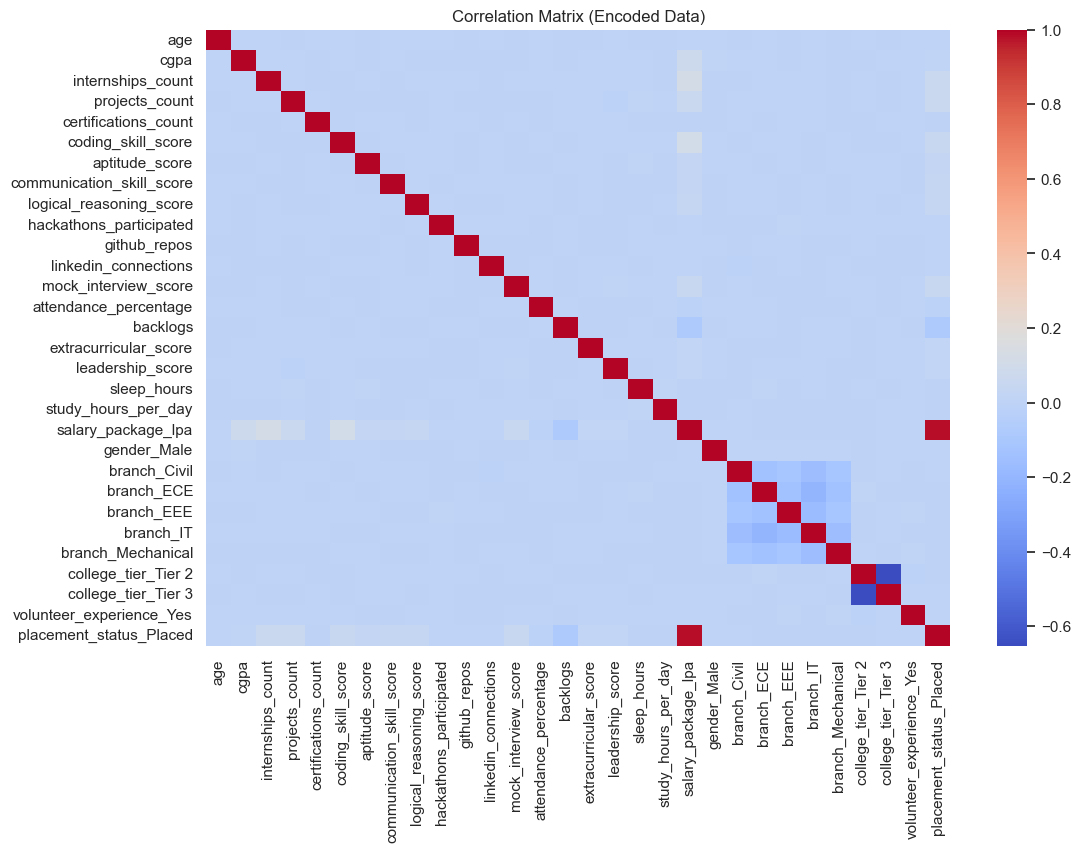

In [105]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Correlation Matrix (Encoded Data)")
plt.show()

### Key Findings

1. Higher coding scores → higher salaries
2. Mock interviews strongly impact placement
3. Internships improve outcomes
4. College tier influence observed

# Step 4: Modeling Preparation

## Classification Model

In [106]:
# Data Preparation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features (IMPORTANT: remove salary to prevent leakage)
X_cls = df.drop(['placement_status', 'salary_package_lpa'], axis=1)

y_cls = df['placement_status']

# One-hot encode ONLY features
X_cls = pd.get_dummies(X_cls, columns=['gender','branch','college_tier','volunteer_experience'], drop_first=True)

# Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

## Train Model

In [117]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print(classification_report(y_test_c, y_pred_c))

Accuracy: 0.5612
              precision    recall  f1-score   support

  Not Placed       0.55      0.21      0.30      9127
      Placed       0.56      0.86      0.68     10873

    accuracy                           0.56     20000
   macro avg       0.56      0.53      0.49     20000
weighted avg       0.56      0.56      0.51     20000



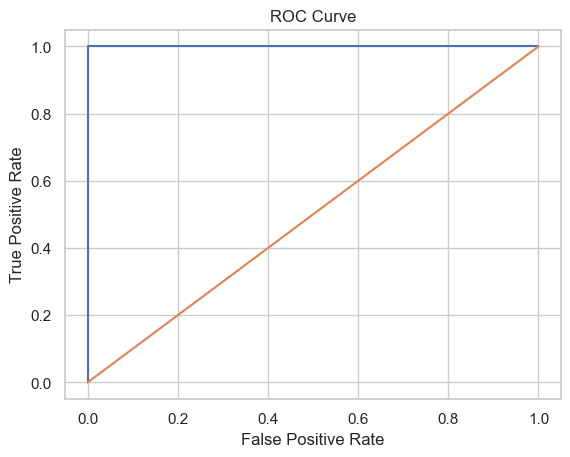

In [118]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])  # diagonal baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Step 5: Regression Model

## Filter placed students

In [132]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")

df.drop('student_id', axis=1, inplace=True)

# FILTER DATA (ONLY PLACED)
# IMPORTANT: salary only makes sense for placed students
df = df[df['placement_status'] == 'Placed'].copy()

# 4. FEATURE ENGINEERING (KEY STEP)
# Total experience
df['total_experience'] = (
    df['internships_count'] +
    df['projects_count'] +
    df['hackathons_participated']
)

# Skill average
df['skill_score'] = (
    df['coding_skill_score'] +
    df['aptitude_score'] +
    df['communication_skill_score']
) / 3

# Experience per age
df['exp_per_year'] = df['total_experience'] / df['age']

# Engagement score
df['engagement_score'] = (
    df['linkedin_connections'] +
    df['github_repos']
)

# Productivity ratio
df['projects_per_internship'] = df['projects_count'] / (df['internships_count'] + 1)

# Academic pressure
df['academic_pressure'] = df['study_hours_per_day'] / (df['sleep_hours'] + 1)

# 5. DEFINE FEATURES & TARGET

X = df.drop(['salary_package_lpa', 'placement_status'], axis=1)
y = df['salary_package_lpa']

# 6. ONE-HOT ENCODING
categorical_cols = ['gender', 'branch', 'college_tier', 'volunteer_experience']

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 7. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. LOG TRANSFORM TARGET (IMPORTANT)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)


# 9. MODEL (XGBOOST - STRONG PERFORMANCE)

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train_log)

# 10. PREDICTION

y_pred_log = model.predict(X_test)

# Convert back to original scale
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

# 11. EVALUATION
r2 = r2_score(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

placed_df = df[df['placement_status'] == 'Placed'].copy()

# Features
X_reg = placed_df.drop(['salary_package_lpa', 'placement_status'], axis=1)
y_reg = placed_df['salary_package_lpa']

# One-hot encode
X_reg = pd.get_dummies(X_reg, columns=['gender','branch','college_tier','volunteer_experience'], drop_first=True)

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Log transform target
y_train_r = np.log1p(y_train_r)
y_test_r = np.log1p(y_test_r)

# Scale
X_train_r = scaler.fit_transform(X_train_r)
X_test_r = scaler.transform(X_test_r)

R2 Score: 0.5947374346999786
RMSE: 1.0132349035454782


# Step 7: Communicate Findings

Key Takeaways:
1. Practical skills outweigh academics in many cases
2. Internships and projects are critical
3. Soft skills influence salary
4. College tier may introduce bias